In [ ]:
import pickle
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
'''
 0   id                 5110 non-null   int64
 1   gender             5110 non-null   object
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64
 4   heart_disease      5110 non-null   int64
 5   ever_married       5110 non-null   object
 6   work_type          5110 non-null   object
 7   Residence_type     5110 non-null   object
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object
 11  stroke             5110 non-null   int64
 '''
# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 1 — CONFIGURACIÓN GLOBAL
#  Taxonomía de variables (Tabla 1 del artículo)
# ══════════════════════════════════════════════════════════════════════════════

# Variables numéricas continuas
NUMERICAL_VARS   = ["age", "avg_glucose_level", "bmi"]

# Categóricas ordinales (no hay variables claramente ordinales con más de dos niveles en este dataset)
ORDINAL_VARS     = []

# Categóricas binarias → se remapean a {0, 1}
BINARY_VARS      = ["hypertension", "heart_disease", "ever_married", "Residence_type"]

# Categóricas nominales multi-clase
NOMINAL_MULTICLASS_VARS = ["gender", "work_type", "smoking_status"]

# Lista completa de features (sin id ni target)
FEATURE_COLS     = NUMERICAL_VARS + ORDINAL_VARS + BINARY_VARS + NOMINAL_MULTICLASS_VARS
CATEGORICAL_VARS = ORDINAL_VARS + BINARY_VARS + NOMINAL_MULTICLASS_VARS
TARGET_VAR       = "stroke"

# Rangos clínicos válidos (referencia para outliers futuros)
CLINICAL_RANGES = {
    "age"             : (0,   120),
    "avg_glucose_level": (50,  300),
    "bmi"             : (10,   70),
    "hypertension"    : (0,     1),
    "heart_disease"   : (0,     1),
}

# Valores categóricos válidos (para post-procesamiento KNN)
CAT_VALID_VALUES = {
    "hypertension"   : [0, 1],
    "heart_disease"  : [0, 1],
    "ever_married"   : [0, 1], # 'Yes'/'No'
    "Residence_type" : [0, 1], # 'Urban'/'Rural'
    "gender"         : [0, 1, 2], # 'Male', 'Female', 'Other' en 0, 1, 2
    "work_type"      : list(range(5)), # ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
    "smoking_status" : list(range(4)), # ['formerly smoked', 'never smoked', 'smokes', 'Unknown']
}


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 2 — CLASE CVDDataPipeline
# ══════════════════════════════════════════════════════════════════════════════

class CVDDataPipeline:
    """
    Pipeline de preparación de datos para modelos CVD.

    Flujo interno de transform()
    ────────────────────────────
    1. Limpieza básica (elimina columna id, resetea índice)
    2. Máscara booleana → detecta qué celdas están vacías
    3. Si hay NaNs  → KNNImputer (distancia Euclidiana, ec. 1 del artículo)
       Si no hay    → base marcada como lista directamente
    4. Post-procesamiento categórico (redondea al valor válido más cercano)
    5. Encoding de categóricas (label o one-hot según el modelo destino)
    6. Retorna X_ready, y, report
    """

    def __init__(self, k_neighbors: int = 5):
        self.k_neighbors = k_neighbors
        self.imputer = KNNImputer(
            n_neighbors=k_neighbors,
            weights="uniform",
            metric="nan_euclidean"      # distancia Euclidiana ignorando NaNs
        )
        self.scaler  = MinMaxScaler()
        self._fitted = False

    # ──────────────────────────────────────────────────────────────────────────
    #  fit()  —  entrenar con base completa (sin NaNs)
    # ──────────────────────────────────────────────────────────────────────────
    def fit(self, df: pd.DataFrame) -> "CVDDataPipeline":
        """
        Entrena el scaler y el KNNImputer con una base COMPLETA.
        Debe llamarse una sola vez antes de cualquier transform().
        """
        df = self._clean(df)
        self._assert_no_nans(df, "fit")

        # Antes de escalar y ajustar el imputer, mapear las categóricas a numéricas
        # para que .values.astype(float) no falle con strings.
        df_temp = df.copy()
        df_temp = self._pre_encode_categorical_strings(df_temp)

        X = df_temp[FEATURE_COLS].values.astype(float)
        self.scaler.fit(X)
        self.imputer.fit(self.scaler.transform(X))

        self._fitted = True
        print(f"[Pipeline] fit() — {len(df)} pacientes | k = {self.k_neighbors}")
        return self

    # ──────────────────────────────────────────────────────────────────────────
    #  transform()  —  preparar base nueva (con o sin NaNs)
    # ──────────────────────────────────────────────────────────────────────────
    def transform(
        self,
        df      : pd.DataFrame,
        encoding: str  = "label",
        verbose : bool = True
    ) -> tuple:
        """
        Prepara una base de datos para modelos predictivos.

        Parámetros
        ----------
        df       : DataFrame de entrada (puede contener NaNs).
        encoding : "label"  → enteros, para RF y XGBoost
                   "onehot" → columnas binarias, para SVM
        verbose  : muestra el reporte del proceso en consola.

        Retorna
        -------
        X_ready : np.ndarray  — features listos para el modelo
        y       : np.ndarray  — target (cardio), None si no está en df
        report  : dict        — diagnóstico del proceso
        """
        if not self._fitted:
            raise RuntimeError("Llama primero a fit() con una base completa.")

        df     = self._clean(df)
        report = {"n_pacientes": len(df), "encoding": encoding}

        # ── Paso 1: máscara booleana ──────────────────────────────────────────
        # Convertir categóricas de texto a numéricas antes de imputar
        df_processed = self._pre_encode_categorical_strings(df.copy())

        missing_mask    = df_processed[FEATURE_COLS].isnull()
        n_missing       = int(missing_mask.values.sum())
        missing_per_col = missing_mask.sum()

        report["missing_detected"] = n_missing > 0
        report["n_missing_total"]  = n_missing
        report["missing_per_col"]  = missing_per_col[missing_per_col > 0].to_dict()

        # ── Paso 2: imputación condicional ────────────────────────────────────
        if n_missing > 0:
            # _impute espera valores numéricos para funcionar correctamente
            df_processed = self._impute(df_processed, missing_mask)
            report["imputation_applied"] = True
            report["n_missing_after"]    = int(df_processed[FEATURE_COLS].isnull().sum().sum())
        else:
            report["imputation_applied"] = False
            report["status"] = "BASE LISTA — sin valores faltantes"

        # ── Paso 3: encoding de categóricas ──────────────────────────────────
        # El encoding final se aplica sobre el df_processed (ya con NaNs imputados y categóricas pre-mapeadas)
        df_enc = self._encode(df_processed, method=encoding)
        report["encoding_applied"]  = encoding
        report["feature_names_out"] = list(df_enc.columns)

        X_ready = df_enc.values.astype(float)
        y = df[TARGET_VAR].values if TARGET_VAR in df.columns else None # Usar el df original para el target

        if verbose:
            self._print_report(report)

        return X_ready, y, report

    # ──────────────────────────────────────────────────────────────────────────
    #  save() / load()
    # ──────────────────────────────────────────────────────────────────────────
    def save(self, path: str) -> None:
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"[Pipeline] Guardado → {path}")

    @staticmethod
    def load(path: str) -> "CVDDataPipeline":
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"[Pipeline] Cargado  → {path}")
        return obj

    # ══════════════════════════════════════════════════════════════════════════
    #  Métodos privados
    # ══════════════════════════════════════════════════════════════════════════

    def _clean(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df.drop(columns=["id"], errors="ignore")
        return df.reset_index(drop=True)

    def _assert_no_nans(self, df: pd.DataFrame, stage: str) -> None:
        n = int(df[FEATURE_COLS].isnull().sum().sum())
        if n > 0:
            raise ValueError(
                f"[Pipeline] {stage}() requiere base SIN NaNs. "
                f"Encontrados: {n} valores faltantes."
            )

    def _pre_encode_categorical_strings(self, df: pd.DataFrame) -> pd.DataFrame:
        """Mapea las variables categóricas de texto a números antes de la imputación."""
        df = df.copy()
        # Mapeos específicos para el dataset de stroke
        if 'gender' in df.columns:
            # Handle 'Other' if it exists, map to a distinct numerical value
            # Assuming 'Female':0, 'Male':1, 'Other':2 or similar
            gender_mapping = {'Female': 0, 'Male': 1, 'Other': 2}
            df['gender'] = df['gender'].map(gender_mapping).fillna(2) # Default to 'Other' if NaN before imputing

        if 'ever_married' in df.columns:
            df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})

        if 'Residence_type' in df.columns:
            df['Residence_type'] = df['Residence_type'].map({'Rural': 0, 'Urban': 1})

        # Para work_type y smoking_status, LabelEncoder es una opción si no se quiere OHE todavía
        # Sin embargo, para KNNImputer, solo necesitamos que sean numéricas.
        # get_dummies también puede hacer esto y luego se consolidan los valores.
        # Para simplificar para KNN, podemos usar factorize o un mapeo manual si los valores son pocos.

        # Para work_type
        if 'work_type' in df.columns:
            work_type_map = {val: i for i, val in enumerate(df['work_type'].dropna().unique())}
            df['work_type'] = df['work_type'].map(work_type_map)

        # Para smoking_status
        if 'smoking_status' in df.columns:
            smoking_status_map = {val: i for i, val in enumerate(df['smoking_status'].dropna().unique())}
            df['smoking_status'] = df['smoking_status'].map(smoking_status_map)

        return df

    def _impute(self, df: pd.DataFrame, missing_mask: pd.DataFrame) -> pd.DataFrame:
        """Escala → imputa con KNN → revierte escala → redondea categóricas."""
        X        = df[FEATURE_COLS].values.astype(float)
        X_scaled = self.scaler.transform(X)               # NaNs se propagan
        X_imp    = self.scaler.inverse_transform(
            self.imputer.transform(X_scaled)
        )
        # Redondear categóricas al valor válido más cercano
        for col in CATEGORICAL_VARS:
            j     = FEATURE_COLS.index(col)
            valid = CAT_VALID_VALUES[col]
            for i in np.where(missing_mask[col].values)[0]:
                X_imp[i, j] = min(valid, key=lambda v: abs(v - X_imp[i, j]))

        df[FEATURE_COLS] = X_imp
        return df

    def _encode(self, df: pd.DataFrame, method: str) -> pd.DataFrame:
        """
        Label Encoding  → para RF y XGBoost (árboles no asumen distancias).
        One-Hot Encoding → para SVM (calcula distancias en espacio de features).
        """
        out = df[FEATURE_COLS].copy()

        if method == "label":
            # Aquí ya las categóricas de texto están mapeadas a números por _pre_encode_categorical_strings
            # Solo necesitamos asegurar que las binarias tengan valores 0/1 y las nominales multi-clase enteros
            return out

        elif method == "onehot":
            parts = [out[NUMERICAL_VARS].copy()]
            for col in CATEGORICAL_VARS:
                # Asegurarse de que los valores sean enteros para get_dummies si vienen de floats imputados
                parts.append(
                    pd.get_dummies(
                        out[col].astype(int), prefix=col, drop_first=True
                    ).astype(int)
                )
            return pd.concat(parts, axis=1)

        else:
            raise ValueError(
                f"encoding debe ser 'label' o 'onehot'. Recibido: '{method}'"
            )

    def _print_report(self, report: dict) -> None:
        sep = "=" * 60
        print(f"\n{sep}")
        print("  CVD DATA PIPELINE — REPORTE DE PROCESAMIENTO")
        print(sep)
        print(f"  Pacientes      : {report['n_pacientes']}")
        print(f"  NaNs detectados: {report['n_missing_total']}")
        if report["missing_detected"]:
            print(f"  KNN Imputer    : APLICADO (k = {self.k_neighbors})")
            print(f"  NaNs restantes : {report.get('n_missing_after', 0)}")
            print("  Por variable   :")
            for col, n in report["missing_per_col"].items():
                print(f"    · {col:<15} {n} celdas")
        else:
            print("  KNN Imputer    : NO REQUERIDO")
            print(f"  → {report.get('status', '')}")
        print(f"  Encoding       : {report['encoding_applied']}")
        print(f"  Features salida: {report['feature_names_out']}")
        print(f"{sep}\n")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 3 — PROCESAMIENTO
#  Leer base → detectar NaNs → entrenar pipeline → X_ready listo para ML
# ══════════════════════════════════════════════════════════════════════════════

def run_processing(
    filepath     : str,
    k_neighbors  : int = 5,
    encoding     : str = "label",
    save_pipeline: str = "pipeline_cvd.pkl",
    save_dataset : str = "cvd_dataset_ready.xlsx",
) -> tuple:
    """
    BLOQUE 3 — PROCESAMIENTO COMPLETO DE LA BASE DE DATOS.

    Pasos
    ─────
    1. Leer el archivo (Excel o CSV)
    2. Inspeccionar columnas, tipos y valores únicos de categóricas
    3. Detectar si hay valores faltantes (máscara booleana)
    4. Entrenar el pipeline con las filas completas disponibles
    5. Aplicar transform() a toda la base (imputa si hay NaNs)
    6. Exportar base lista y pipeline entrenado

    Parámetros
    ──────────
    filepath      : ruta al archivo de datos (.xlsx o .csv).
    k_neighbors   : número de vecinos para KNNImputer.
    encoding      : "label" (RF/XGBoost) o "onehot" (SVM).
    save_pipeline : ruta para guardar el pipeline entrenado (.pkl).
    save_dataset  : ruta para exportar la base lista (.xlsx).

    Retorna
    ───────
    pipeline : CVDDataPipeline entrenado
    X_ready  : np.ndarray — features listos para modelos ML
    y        : np.ndarray — vector target (cardio)
    df_clean : pd.DataFrame — base procesada (para referencia)
    """
    sep = "=" * 65
    print(f"\n{sep}")
    print("  BLOQUE 3 — PROCESAMIENTO")
    print(sep)

    # ── 1. Leer archivo ───────────────────────────────────────────────────────
    if filepath.lower().endswith(".csv"):
        df = pd.read_csv(filepath, sep=";")
    else:
        df = pd.read_excel(filepath)

    df.columns = df.columns.str.strip()
    df = df.drop(columns=["id"], errors="ignore").reset_index(drop=True)

    print(f"\n  Archivo  : {filepath}")
    print(f"  Forma    : {df.shape[0]} pacientes × {df.shape[1]} variables")

    # ── 2. Inspección de variables ────────────────────────────────────────────
    print(f"\n  {'─'*60}")
    print("  INSPECCIÓN DE VARIABLES")
    print(f"  {'─'*60}")
    print(f"  {'Variable':<16} {'Tipo':<12} {'Nulos':<8} {'Únicos / Rango'}")
    print(f"  {'─'*16} {'─'*12} {'─'*8} {'─'*25}")

    for col in FEATURE_COLS:
        if col not in df.columns:
            print(f"  {col:<16} NO ENCONTRADA EN EL ARCHIVO")
            continue
        nulos = int(df[col].isnull().sum())
        if col in NUMERICAL_VARS:
            rango = f"[{df[col].min():.1f} – {df[col].max():.1f}]"
            tipo  = "numérica"
        else:
            # Handle potential non-integer categorical values after imputation/mapping
            # Convert to object type for unique values check if it's not already, then try to convert to int
            unique_vals = df[col].dropna().unique()
            try:
                unicos = sorted(unique_vals.astype(int).tolist())
            except ValueError:
                # If conversion to int fails (e.g., still float after some operations), just show as is
                unicos = sorted(unique_vals.tolist())
            rango  = str(unicos)
            tipo   = "categórica"
        print(f"  {col:<16} {tipo:<12} {nulos:<8} {rango}")

    # ── 3. Máscara booleana de NaNs ───────────────────────────────────────────
    missing_mask = df[FEATURE_COLS].isnull()
    n_missing    = int(missing_mask.values.sum())

    print(f"\n  {'─'*60}")
    print("  ESTADO DE LA BASE")
    print(f"  {'─'*60}")
    if n_missing == 0:
        print("   BASE COMPLETA — no hay valores faltantes.")
        print("    El pipeline se entrenará con todos los pacientes.")
        df_train_source = df.copy()
    else:
        pct = n_missing / (len(df) * len(FEATURE_COLS)) * 100
        print(f"   {n_missing} valores faltantes detectados ({pct:.1f}% del total).")
        print("    Detalle:")
        for col in FEATURE_COLS:
            n = int(missing_mask[col].sum())
            if n > 0:
                print(f"    · {col:<15} {n} celdas faltantes")
        # Entrenar solo con filas completamente observadas
        df_train_source = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
        print(f"\n    Filas completas para entrenamiento: {len(df_train_source)}")

    # ── 4. Entrenar pipeline ──────────────────────────────────────────────────
    print(f"\n  {'─'*60}")
    print("  ENTRENAMIENTO DEL PIPELINE")
    print(f"  {'─'*60}")
    pipeline = CVDDataPipeline(k_neighbors=k_neighbors)
    pipeline.fit(df_train_source)

    # ── 5. Transformar la base completa ───────────────────────────────────────
    print(f"\n  {'─'*60}")
    print("  TRANSFORMACIÓN DE LA BASE")
    print(f"  {'─'*60}")
    X_ready, y, report = pipeline.transform(df, encoding=encoding, verbose=True)

    # ── 6. Guardar outputs ────────────────────────────────────────────────────
    pipeline.save(save_pipeline)

    df_export = pd.DataFrame(X_ready, columns=report["feature_names_out"])
    if y is not None:
        df_export.insert(0, TARGET_VAR, y)
    df_export.to_excel(save_dataset, index=False)
    print(f"[Procesamiento] Dataset exportado → {save_dataset}")

    print(f"\n{sep}")
    print("  PROCESAMIENTO FINALIZADO")
    print(f"  X_ready shape : {X_ready.shape}")
    print(f"  Encoding      : {encoding}")
    print(f"  Pipeline      → {save_pipeline}")
    print(f"  Dataset listo → {save_dataset}")
    print(f"{sep}\n")

    return pipeline, X_ready, y, df_export

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 4 — VALIDACIÓN
#  Inyectar NaNs → imputar con KNN entrenado → medir error vs. original
# ══════════════════════════════════════════════════════════════════════════════

def run_validation(
    pipeline        : CVDDataPipeline,
    df_referencia   : pd.DataFrame,
    missing_rate_num: float = 0.15,
    missing_rate_cat: float = 0.10,
    k_candidates    : list  = None,
    random_seed     : int   = 42,
    save_plot       : str   = "validacion_knn.png",
    save_excel      : str   = "validacion_detalle.xlsx",
) -> pd.DataFrame:
    """
    BLOQUE 4 — VALIDACIÓN DEL KNN IMPUTER.

    Pasos
    ─────
    1. Recibe base de referencia COMPLETA (ground-truth)
    2. Opcionalmente: busca el mejor k entre k_candidates
    3. Inyecta NaNs aleatorios en posiciones controladas
    4. Imputa con el pipeline ya entrenado (solo .transform())
    5. Compara celda a celda: imputado vs. original
    6. Reporta RMSE + error relativo (%) para numéricas
               Accuracy (%) para categóricas
    7. Genera gráfica diagnóstica y Excel detallado por paciente

    Parámetros
    ──────────
    pipeline         : CVDDataPipeline entrenado (salida de run_processing).
    df_referencia    : DataFrame completo sin NaNs (base de referencia).
    missing_rate_num : fracción de celdas numéricas a borrar (default 15%).
    missing_rate_cat : fracción de celdas categóricas a borrar (default 10%).
    k_candidates     : lista de k a probar [3,5,7,10]. None = saltar búsqueda.
    random_seed      : semilla para reproducibilidad.
    save_plot        : ruta para guardar la gráfica de validación.
    save_excel       : ruta para guardar tabla detallada paciente × variable.

    Retorna
    ───────
    df_metricas : DataFrame con métricas resumidas por variable
    """
    np.random.seed(random_seed)
    sep = "=" * 65

    print(f"\n{sep}")
    print("  BLOQUE 4 — VALIDACIÓN")
    print(sep)

    # Preparar base de referencia
    df_ref = pipeline._clean(df_referencia).reset_index(drop=True)
    pipeline._assert_no_nans(df_ref, "validación")
    print(f"\n  Base de referencia : {len(df_ref)} pacientes (sin NaNs)")
    print(f"  Tasa NaNs numéricos : {missing_rate_num*100:.0f}%")
    print(f"  Tasa NaNs categóric.: {missing_rate_cat*100:.0f}%")

    # ── Paso 4.1 (opcional): búsqueda del mejor k ─────────────────────────────
    if k_candidates is not None:
        print(f"\n  {'─'*60}")
        print(f"  BÚSQUEDA DE MEJOR k — candidatos: {k_candidates}")
        print(f"  {'─'*60}")
        best_k = _select_best_k(
            df_ref, k_candidates,
            missing_rate_num, missing_rate_cat, random_seed
        )
        pipeline.k_neighbors = best_k
        pipeline.imputer = KNNImputer(
            n_neighbors=best_k, weights="uniform", metric="nan_euclidean"
        )
        pipeline.fit(df_ref)
        print(f"  → Pipeline re-entrenado con k = {best_k}")
    else:
        print(f"\n  k actual del pipeline = {pipeline.k_neighbors}")

    # ── Paso 4.2: inyectar NaNs aleatorios ───────────────────────────────────
    df_missing = df_ref.copy()
    nan_mask   = pd.DataFrame(False, index=df_ref.index, columns=FEATURE_COLS)

    for col in NUMERICAL_VARS:
        n    = max(1, int(len(df_ref) * missing_rate_num))
        rows = np.random.choice(len(df_ref), n, replace=False)
        df_missing.loc[rows, col] = np.nan
        nan_mask.loc[rows, col]   = True

    for col in CATEGORICAL_VARS:
        n    = max(1, int(len(df_ref) * missing_rate_cat))
        rows = np.random.choice(len(df_ref), n, replace=False)
        df_missing.loc[rows, col] = np.nan
        nan_mask.loc[rows, col]   = True

    n_total = int(nan_mask.values.sum())
    print(f"\n  NaNs inyectados : {n_total} celdas "
          f"({n_total / nan_mask.size * 100:.1f}% del total)")
    print(f"\n  {'Variable':<16} {'Tipo':<12} {'Celdas borradas'}")
    print(f"  {'─'*16} {'─'*12} {'─'*15}")
    for col in FEATURE_COLS:
        n   = int(nan_mask[col].sum())
        tip = "numérica" if col in NUMERICAL_VARS else "categórica"
        print(f"  {col:<16} {tip:<12} {n}")

    # ── Paso 4.3: imputar con pipeline entrenado ──────────────────────────────
    df_miss_clean    = pipeline._clean(df_missing)
    missing_mask_loc = df_miss_clean[FEATURE_COLS].isnull()
    df_imputado      = pipeline._impute(
        df_miss_clean.copy(), missing_mask_loc
    ).reset_index(drop=True)

    # ── Paso 4.4: comparar celda a celda ─────────────────────────────────────
    X_ref = df_ref[FEATURE_COLS].values.astype(float)
    X_imp = df_imputado[FEATURE_COLS].values.astype(float)

    records     = []
    detail_rows = []

    for j, col in enumerate(FEATURE_COLS):
        affected = np.where(nan_mask[col].values)[0]
        if len(affected) == 0:
            continue

        orig = X_ref[affected, j]
        imp  = X_imp[affected, j]
        err  = imp - orig

        # Detalle paciente por paciente
        for idx, i in enumerate(affected):
            detail_rows.append({
                "paciente_idx"    : int(i),
                "variable"        : col,
                "tipo"            : "numérica" if col in NUMERICAL_VARS else "categórica",
                "valor_original"  : round(float(orig[idx]), 3),
                "valor_imputado"  : round(float(imp[idx]),  3),
                "error (imp-orig)": round(float(err[idx]),  3),
            })

        if col in NUMERICAL_VARS:
            rmse      = float(np.sqrt(np.mean(err ** 2)))
            mae       = float(np.mean(np.abs(err)))
            rango     = float(X_ref[:, j].max() - X_ref[:, j].min())
            err_rel   = round(rmse / rango * 100, 2) if rango > 0 else np.nan
            veredicto = "✓ bueno" if err_rel < 10 else "⚠ revisar"
            records.append({
                "variable"    : col,
                "tipo"        : "numérica",
                "n_imputadas" : len(affected),
                "RMSE"        : round(rmse, 4),
                "MAE"         : round(mae, 4),
                "error_rel_%" : err_rel,
                "Accuracy"    : "—",
                "veredicto"   : veredicto,
            })
        else:
            acc       = float(np.mean(
                orig.astype(int) == np.round(imp).astype(int)
            ))
            veredicto = "✓ bueno" if acc >= 0.80 else "⚠ revisar"
            records.append({
                "variable"    : col,
                "tipo"        : "categórica",
                "n_imputadas" : len(affected),
                "RMSE"        : "—",
                "MAE"         : "—",
                "error_rel_%" : "—",
                "Accuracy"    : round(acc, 4),
                "veredicto"   : veredicto,
            })

    df_metricas = pd.DataFrame(records)
    df_detalle  = pd.DataFrame(detail_rows)

    # ── Paso 4.5: imprimir resumen ────────────────────────────────────────────
    print(f"\n  {'─'*65}")
    print("  MÉTRICAS DE VALIDACIÓN POR VARIABLE")
    print(f"  {'─'*65}")
    print(f"  {'Variable':<16} {'Tipo':<12} {'RMSE':<8} {'Err.rel%':<10}"
          f"{'Accuracy':<10} {'N imp.':<8} Veredicto")
    print(f"  {'─'*16} {'─'*12} {'─'*8} {'─'*10} {'─'*10} {'─'*8} {'─'*10}")
    for _, row in df_metricas.iterrows():
        rmse_s = f"{row['RMSE']}" if row["tipo"] == "numérica" else "   —"
        rel_s  = f"{row['error_rel_%']}%" if row["tipo"] == "numérica" else "   —"
        acc_s  = f"{row['Accuracy']}" if row["tipo"] == "categórica" else "   —"
        print(f"  {row['variable']:<16} {row['tipo']:<12} {rmse_s:<8} "
              f"{rel_s:<10} {acc_s:<10} {row['n_imputadas']:<8} {row['veredicto']}")

    # Resumen agregado
    num_rows = df_metricas[df_metricas["tipo"] == "numérica"]
    cat_rows = df_metricas[df_metricas["tipo"] == "categórica"]
    rmse_avg = pd.to_numeric(num_rows["RMSE"],        errors="coerce").mean()
    rel_avg  = pd.to_numeric(num_rows["error_rel_%"], errors="coerce").mean()
    acc_avg  = pd.to_numeric(cat_rows["Accuracy"],    errors="coerce").mean()
    ok_num   = (num_rows["veredicto"] == "✓ bueno").sum()
    ok_cat   = (cat_rows["veredicto"] == "✓ bueno").sum()

    print(f"\n  {'─'*65}")
    print(f"  Numéricas   : {ok_num}/{len(num_rows)} OK  "
          f"| RMSE prom. = {rmse_avg:.4f}  | Error rel. = {rel_avg:.2f}%")
    print(f"  Categóricas : {ok_cat}/{len(cat_rows)} OK  "
          f"| Accuracy media = {acc_avg*100:.1f}%")

    revisar = df_metricas[df_metricas["veredicto"] == "⚠ revisar"]["variable"].tolist()
    if revisar:
        print(f"\n  ⚠ Variables fuera de umbral: {revisar}")
        print("    → Considera probar k_candidates o revisar la base de entrenamiento.")
    else:
        print("\n  → Todas las variables dentro de los umbrales aceptables.")
    print(f"  {'─'*65}")

    # ── Paso 4.6: gráficas ────────────────────────────────────────────────────
    if save_plot:
        _plot_validation(
            X_ref, X_imp, nan_mask, df_metricas,
            pipeline.k_neighbors, save_plot
        )

    # ── Paso 4.7: Excel detallado ─────────────────────────────────────────────
    if save_excel:
        with pd.ExcelWriter(save_excel, engine="openpyxl") as writer:
            df_metricas.to_excel(writer, sheet_name="Metricas_resumen",     index=False)
            df_detalle.to_excel(writer,  sheet_name="Detalle_por_paciente", index=False)
        print(f"\n[Validación] Excel guardado → {save_excel}")

    print(f"\n{sep}")
    print("  VALIDACIÓN FINALIZADA")
    print(f"{sep}\n")

    return df_metricas


# ══════════════════════════════════════════════════════════════════════════════
#  Funciones auxiliares privadas del Bloque 4
# ══════════════════════════════════════════════════════════════════════════════

def _select_best_k(
    df_ref          : pd.DataFrame,
    k_candidates    : list,
    missing_rate_num: float,
    missing_rate_cat: float,
    random_seed     : int,
) -> int:
    """
    Evalúa cada k en k_candidates inyectando NaNs y midiendo error.
    Elige el k con menor score = RMSE_relativo_promedio − Accuracy_promedio*100.
    Usa la misma máscara de NaNs para todos los k (comparación justa).
    """
    np.random.seed(random_seed)

    # Generar máscara una sola vez
    df_miss = df_ref.copy()
    mask    = pd.DataFrame(False, index=df_ref.index, columns=FEATURE_COLS)
    for col in NUMERICAL_VARS:
        n    = max(1, int(len(df_ref) * missing_rate_num))
        rows = np.random.choice(len(df_ref), n, replace=False)
        df_miss.loc[rows, col] = np.nan
        mask.loc[rows, col]    = True
    for col in CATEGORICAL_VARS:
        n    = max(1, int(len(df_ref) * missing_rate_cat))
        rows = np.random.choice(len(df_ref), n, replace=False)
        df_miss.loc[rows, col] = np.nan
        mask.loc[rows, col]    = True

    X_ref_arr  = df_ref[FEATURE_COLS].values.astype(float)
    resultados = {}

    print(f"\n  {'k':<6} {'RMSE rel. prom.':<20} {'Accuracy prom.':<18} Score")
    print(f"  {'─'*6} {'─'*20} {'─'*18} {'─'*10}")

    for k in k_candidates:
        pipe_k = CVDDataPipeline(k_neighbors=k)
        pipe_k.fit(df_ref)

        df_mc  = pipe_k._clean(df_miss.copy())
        df_imp = pipe_k._impute(df_mc, df_mc[FEATURE_COLS].isnull())
        X_imp  = df_imp.reset_index(drop=True)[FEATURE_COLS].values.astype(float)

        rmse_rels, accs = [], []
        for j, col in enumerate(FEATURE_COLS):
            aff = np.where(mask[col].values)[0]
            if len(aff) == 0:
                continue
            orig = X_ref_arr[aff, j]
            imp  = X_imp[aff, j]
            if col in NUMERICAL_VARS:
                rng = X_ref_arr[:, j].max() - X_ref_arr[:, j].min()
                if rng > 0:
                    rmse_rels.append(
                        np.sqrt(np.mean((orig - imp) ** 2)) / rng * 100
                    )
            else:
                accs.append(
                    np.mean(orig.astype(int) == np.round(imp).astype(int))
                )

        rmse_avg = float(np.mean(rmse_rels)) if rmse_rels else 0.0
        acc_avg  = float(np.mean(accs))      if accs      else 0.0
        score    = rmse_avg - acc_avg * 100
        resultados[k] = {
            "rmse_avg": rmse_avg,
            "acc_avg" : acc_avg,
            "score"   : score,
        }
        print(f"  {k:<6} {rmse_avg:<20.3f} {acc_avg*100:<18.1f}% {score:.3f}")

    best_k = min(resultados, key=lambda k: resultados[k]["score"])
    print(f"\n  → Mejor k : {best_k}  "
          f"(RMSE rel={resultados[best_k]['rmse_avg']:.2f}%  "
          f"Acc={resultados[best_k]['acc_avg']*100:.1f}%)")
    return best_k


def _plot_validation(
    X_ref      : np.ndarray,
    X_imp      : np.ndarray,
    nan_mask   : pd.DataFrame,
    df_metricas: pd.DataFrame,
    k          : int,
    save_path  : str,
) -> None:
    """
    Gráfica completa de validación:
      Fila 0-1 : scatter original vs. imputado para cada variable numérica
      Fila 1-3 : histograma de errores | barras accuracy | barras RMSE | tabla
    """
    from matplotlib.patches import Patch

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        f"Validación KNN Imputer  (k = {k})\n"
        "Original vs. Imputado por variable",
        fontsize=14, fontweight="bold", y=0.99
    )
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.40)

    # ── Fila 0-1: scatter por variable numérica ───────────────────────────────
    for idx, col in enumerate(NUMERICAL_VARS):
        ax  = fig.add_subplot(gs[idx // 4, idx % 4])
        j   = FEATURE_COLS.index(col)
        aff = np.where(nan_mask[col].values)[0]
        if len(aff) == 0:
            ax.axis("off"); continue
        orig = X_ref[aff, j]
        imp  = X_imp[aff, j]
        ax.scatter(orig, imp, alpha=0.65, color="#9b59b6",
                   edgecolors="white", s=50, linewidths=0.4)
        lim = [min(orig.min(), imp.min()) - 1,
               max(orig.max(), imp.max()) + 1]
        ax.plot(lim, lim, "--", color="#888", linewidth=1, label="ideal")
        row = df_metricas[df_metricas["variable"] == col]
        if not row.empty:
            r = row.iloc[0]
            ax.set_title(
                f"{col}\nRMSE={r['RMSE']}  err%={r['error_rel_%']}  {r['veredicto']}",
                fontsize=8, fontweight="bold"
            )
        ax.set_xlabel("Original"); ax.set_ylabel("Imputado")
        ax.legend(fontsize=7)

    # ── Fila 1 col 3: histograma de errores para ap_hi ────────────────────────
    ax_err = fig.add_subplot(gs[1, 3])
    j_ap   = FEATURE_COLS.index("ap_hi")
    aff_ap = np.where(nan_mask["ap_hi"].values)[0]
    if len(aff_ap) > 0:
        errs = X_imp[aff_ap, j_ap] - X_ref[aff_ap, j_ap]
        ax_err.hist(errs, bins=12, color="#e09a3a", edgecolor="white")
        ax_err.axvline(0, color="red", linestyle="--",
                       lw=1.2, label="error = 0")
        ax_err.axvline(errs.mean(), color="#333", linestyle="-",
                       lw=1, label=f"media = {errs.mean():.1f}")
        ax_err.set_title("Distribución de errores\nap_hi  (imp − orig)",
                         fontweight="bold", fontsize=9)
        ax_err.set_xlabel("Error (mmHg)"); ax_err.set_ylabel("Frecuencia")
        ax_err.legend(fontsize=8)

    # ── Fila 2 col 0: Accuracy categóricas ────────────────────────────────────
    ax_cat = fig.add_subplot(gs[2, 0])
    cat_m  = df_metricas[df_metricas["tipo"] == "categórica"].copy()
    cat_m["acc_f"] = pd.to_numeric(cat_m["Accuracy"], errors="coerce")
    c_bars = ["#5cb85c" if v == "✓ bueno" else "#e05c5c"
              for v in cat_m["veredicto"]]
    bars = ax_cat.barh(cat_m["variable"], cat_m["acc_f"],
                       color=c_bars, edgecolor="white")
    ax_cat.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax_cat.axvline(0.80, color="gray", linestyle="--",
                   lw=0.8, label="umbral 80%")
    ax_cat.set_xlim(0, 1.25); ax_cat.legend(fontsize=7)
    ax_cat.set_title("Accuracy — categóricas\n(verde ≥ 80%)",
                     fontweight="bold", fontsize=9)
    ax_cat.set_xlabel("Accuracy")

    # ── Fila 2 col 1: RMSE relativo numéricas ─────────────────────────────────
    ax_rmse = fig.add_subplot(gs[2, 1])
    num_m   = df_metricas[df_metricas["tipo"] == "numérica"].copy()
    num_m["rel_f"] = pd.to_numeric(num_m["error_rel_%"], errors="coerce")
    c_bars2 = ["#5cb85c" if v == "✓ bueno" else "#e05c5c"
               for v in num_m["veredicto"]]
    bars2 = ax_rmse.barh(num_m["variable"], num_m["rel_f"],
                         color=c_bars2, edgecolor="white")
    ax_rmse.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax_rmse.axvline(10, color="gray", linestyle="--",
                    lw=0.8, label="umbral 10%")
    ax_rmse.legend(fontsize=7)
    ax_rmse.set_title("Error relativo — numéricas\n(verde < 10% del rango)",
                      fontweight="bold", fontsize=9)
    ax_rmse.set_xlabel("Error relativo (%)")

    # ── Fila 2 col 2: mapa de NaNs ────────────────────────────────────────────
    ax_map = fig.add_subplot(gs[2, 2])
    sns.heatmap(
        nan_mask[FEATURE_COLS].T.astype(int), ax=ax_map,
        cmap=["#d9f0f7", "#e05c5c"], cbar=False,
        linewidths=0, xticklabels=False
    )
    ax_map.set_title("Mapa de NaNs inyectados\n(rojo = faltante)",
                     fontweight="bold", fontsize=9)
    ax_map.set_xlabel("Pacientes →")
    ax_map.legend(
        handles=[Patch(facecolor="#d9f0f7", label="Observado"),
                 Patch(facecolor="#e05c5c",  label="Faltante")],
        loc="upper right", fontsize=7
    )

    # ── Fila 2 col 3: tabla de veredictos ─────────────────────────────────────
    ax_tbl = fig.add_subplot(gs[2, 3])
    ax_tbl.axis("off")
    tbl_data = df_metricas[["variable", "veredicto"]].values.tolist()
    tbl = ax_tbl.table(
        cellText=tbl_data,
        colLabels=["Variable", "Veredicto"],
        loc="center", cellLoc="center"
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.1, 1.4)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#4a90d9")
            cell.set_text_props(color="white", fontweight="bold")
        elif r <= len(tbl_data):
            color = "#d4edda" if tbl_data[r-1][1] == "✓ bueno" else "#f8d7da"
            cell.set_facecolor(color)
    ax_tbl.set_title("Resumen veredictos", fontweight="bold", fontsize=9)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[Validación] Gráfica guardada → {save_path}")


In [ ]:


# ══════════════════════════════════════════════════════════════════════════════
#  PUNTO DE ENTRADA
#  Configura las rutas y ejecuta los dos bloques en orden
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":


    ARCHIVO_DATOS  = "/content/cardio_train.csv"
    PIPELINE_PKL   = "pipeline_cvd.pkl"
    DATASET_LISTO  = "cvd_dataset_ready.xlsx"
    PLOT_VALID     = "validacion_knn.png"
    EXCEL_VALID    = "validacion_detalle.xlsx"

    #  BLOQUE 3 — PROCESAMIENTO

    pipeline, X_ready, y, df_clean = run_processing(
        filepath      = ARCHIVO_DATOS,
        k_neighbors   = 5,        # valor inicial
        encoding      = "label",  # "label" → RF/XGBoost  |  "onehot" → SVM
        save_pipeline = PIPELINE_PKL,
        save_dataset  = DATASET_LISTO,
    )

    print(f"X_ready listo para modelos: {X_ready.shape}")




  BLOQUE 3 — PROCESAMIENTO

  Archivo  : /content/cardio_train.csv
  Forma    : 70000 pacientes × 12 variables

  ────────────────────────────────────────────────────────────
  INSPECCIÓN DE VARIABLES
  ────────────────────────────────────────────────────────────
  Variable         Tipo         Nulos    Únicos / Rango
  ──────────────── ──────────── ──────── ─────────────────────────
  age              numérica     0        [10798.0 – 23713.0]
  height           numérica     0        [55.0 – 250.0]
  weight           numérica     0        [10.0 – 200.0]
  ap_hi            numérica     0        [-150.0 – 16020.0]
  ap_lo            numérica     0        [-70.0 – 11000.0]
  cholesterol      categórica   0        [1, 2, 3]
  gluc             categórica   0        [1, 2, 3]
  gender           categórica   0        [1, 2]
  smoke            categórica   0        [0, 1]
  alco             categórica   0        [0, 1]
  active           categórica   0        [0, 1]

  ───────────────────────

In [ ]:
    # ══════════════════════════════════════════════════════════════════════
    #  BLOQUE 4 — VALIDACIÓN
    # ══════════════════════════════════════════════════════════════════════

    # Usar la base original completa como referencia (ground-truth)
    df_ref = pd.read_csv(ARCHIVO_DATOS, sep=";")
    df_ref.columns = df_ref.columns.str.strip()

    metricas = run_validation(
        pipeline         = pipeline,
        df_referencia    = df_ref,
        missing_rate_num = 0.15,          # borrar 15% de celdas numéricas
        missing_rate_cat = 0.10,          # borrar 10% de celdas categóricas
        k_candidates     = [3, 5, 7, 10], # None para saltar búsqueda de k
        random_seed      = 42,
        save_plot        = PLOT_VALID,
        save_excel       = EXCEL_VALID,
    )

    # Copiar outputs al directorio de salida
    for f in [PIPELINE_PKL, DATASET_LISTO, PLOT_VALID, EXCEL_VALID]:
        try:
            shutil.copy(f, f"/mnt/user-data/outputs/{f}")
        except Exception:
            pass


  BLOQUE 4 — VALIDACIÓN

  Base de referencia : 70000 pacientes (sin NaNs)
  Tasa NaNs numéricos : 15%
  Tasa NaNs categóric.: 10%

  ────────────────────────────────────────────────────────────
  BÚSQUEDA DE MEJOR k — candidatos: [3, 5, 7, 10]
  ────────────────────────────────────────────────────────────

  k      RMSE rel. prom.      Accuracy prom.     Score
  ────── ──────────────────── ────────────────── ──────────
[Pipeline] fit() — 70000 pacientes | k = 3
  3      5.881                76.5              % -70.604
[Pipeline] fit() — 70000 pacientes | k = 5
  5      6.042                76.7              % -70.691
[Pipeline] fit() — 70000 pacientes | k = 7
  7      6.137                76.1              % -69.935
[Pipeline] fit() — 70000 pacientes | k = 10
  10     6.195                76.3              % -70.059

  → Mejor k : 5  (RMSE rel=6.04%  Acc=76.7%)
[Pipeline] fit() — 70000 pacientes | k = 5
  → Pipeline re-entrenado con k = 5

  NaNs inyectados : 94500 celdas (12.3% del 

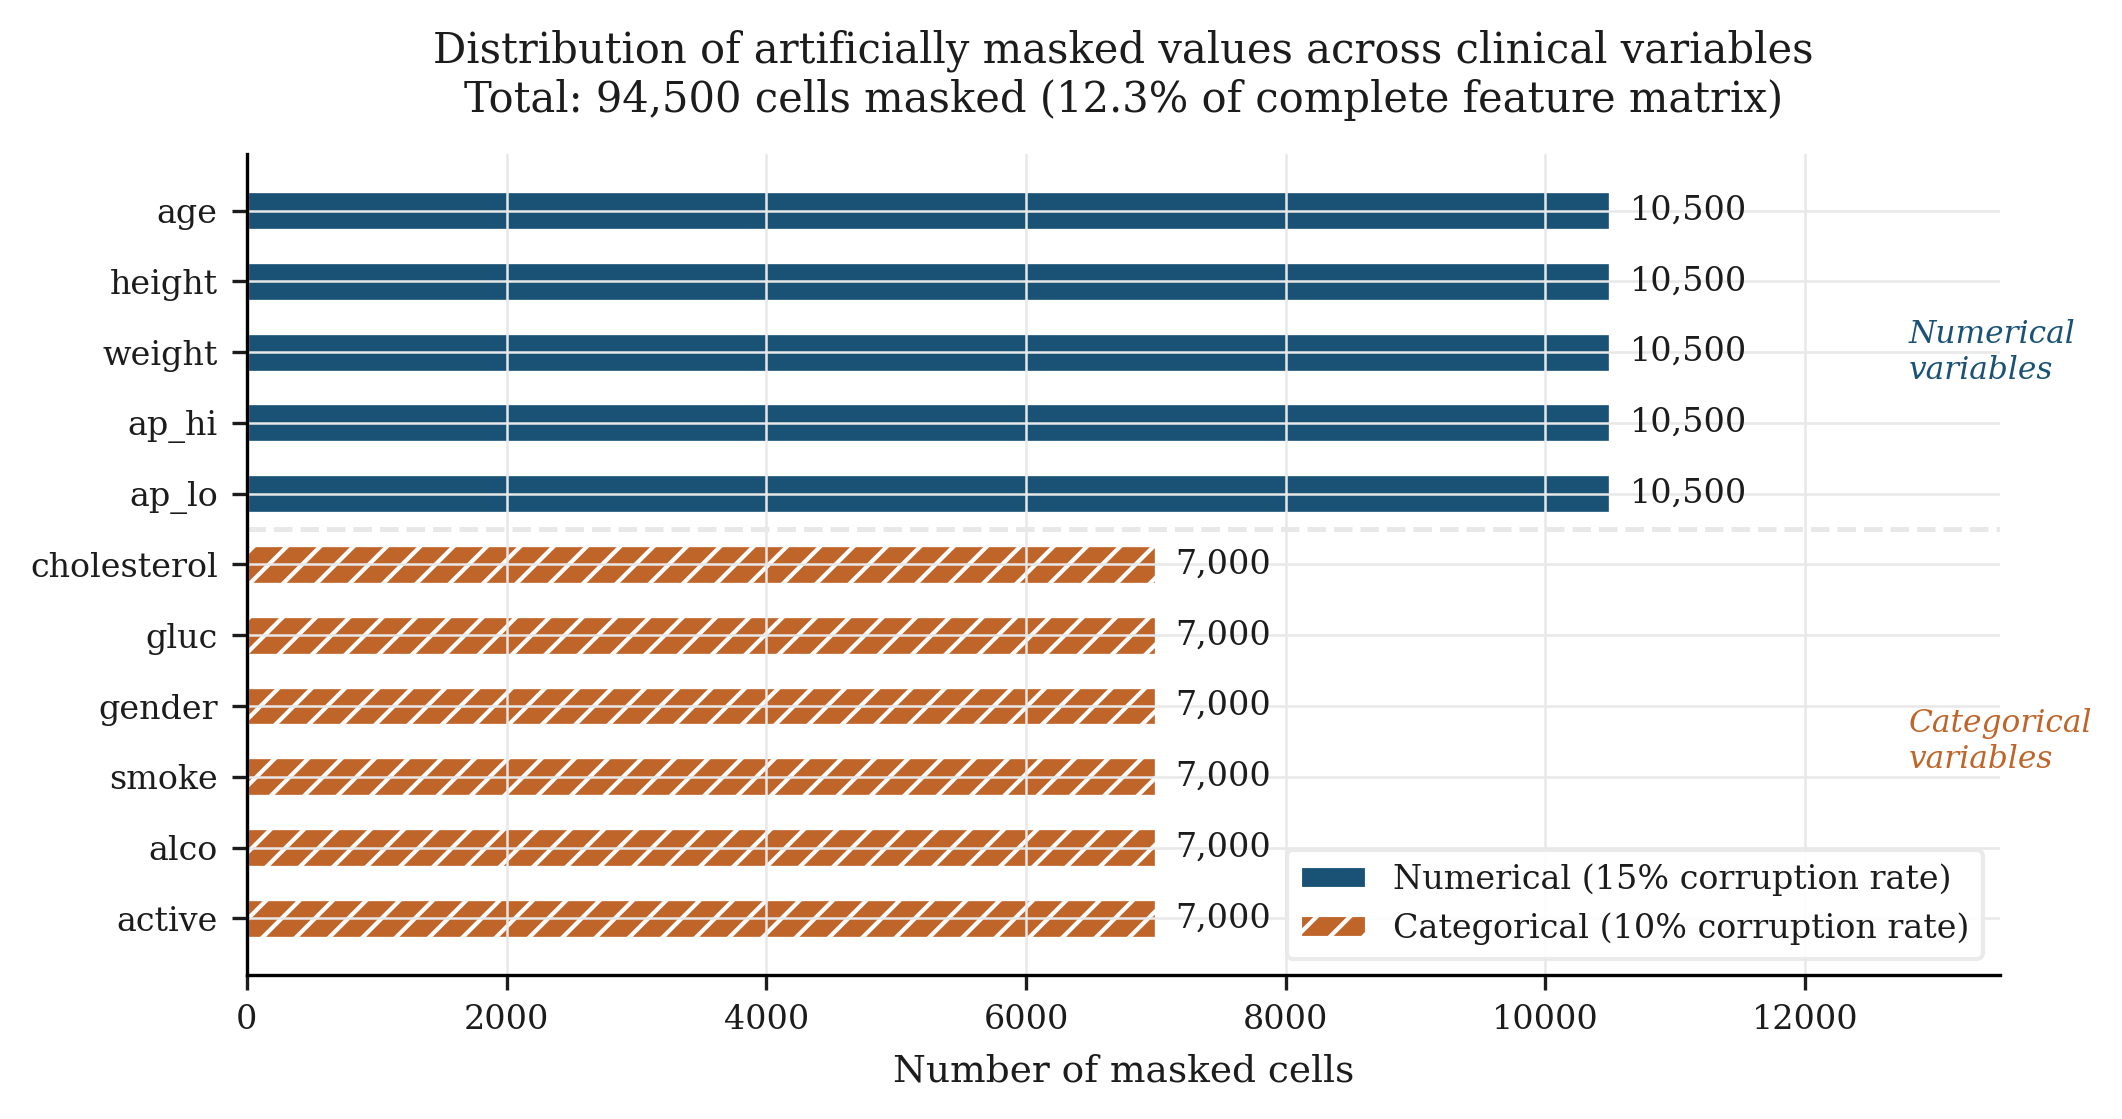

Figura 2 lista.


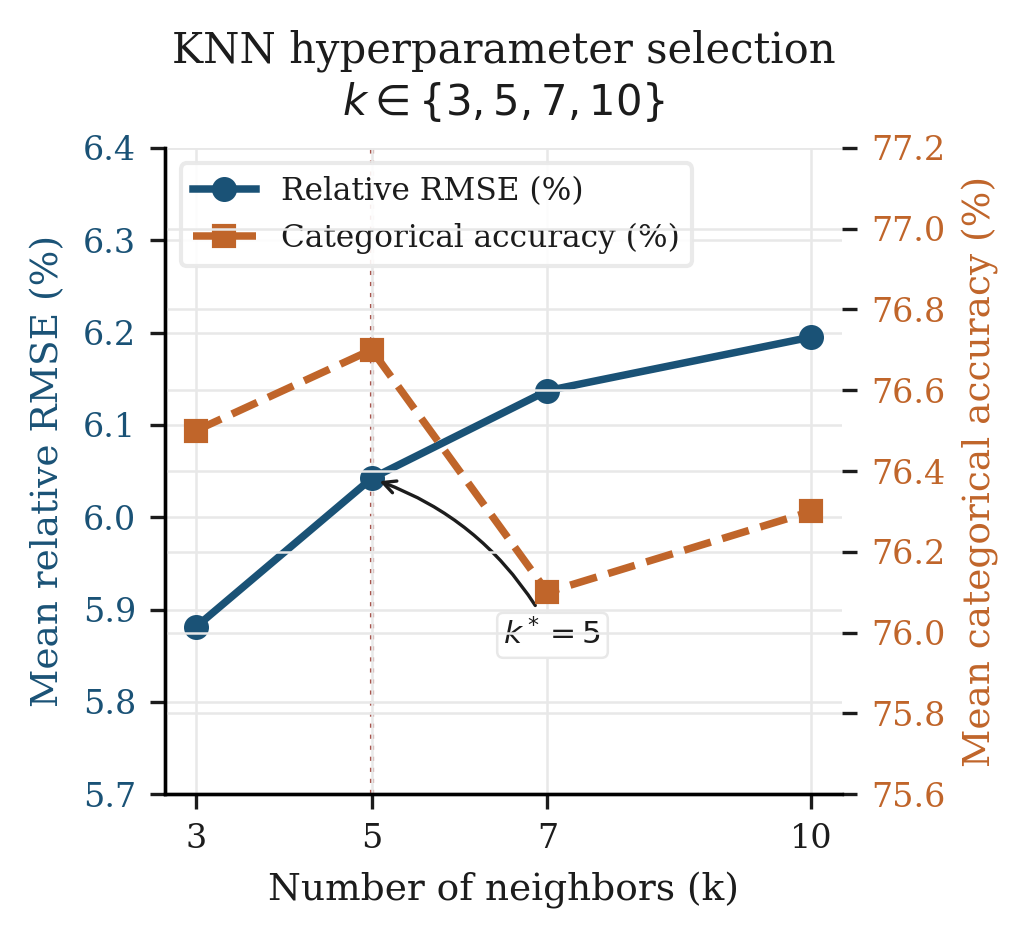

Figura 3 lista.


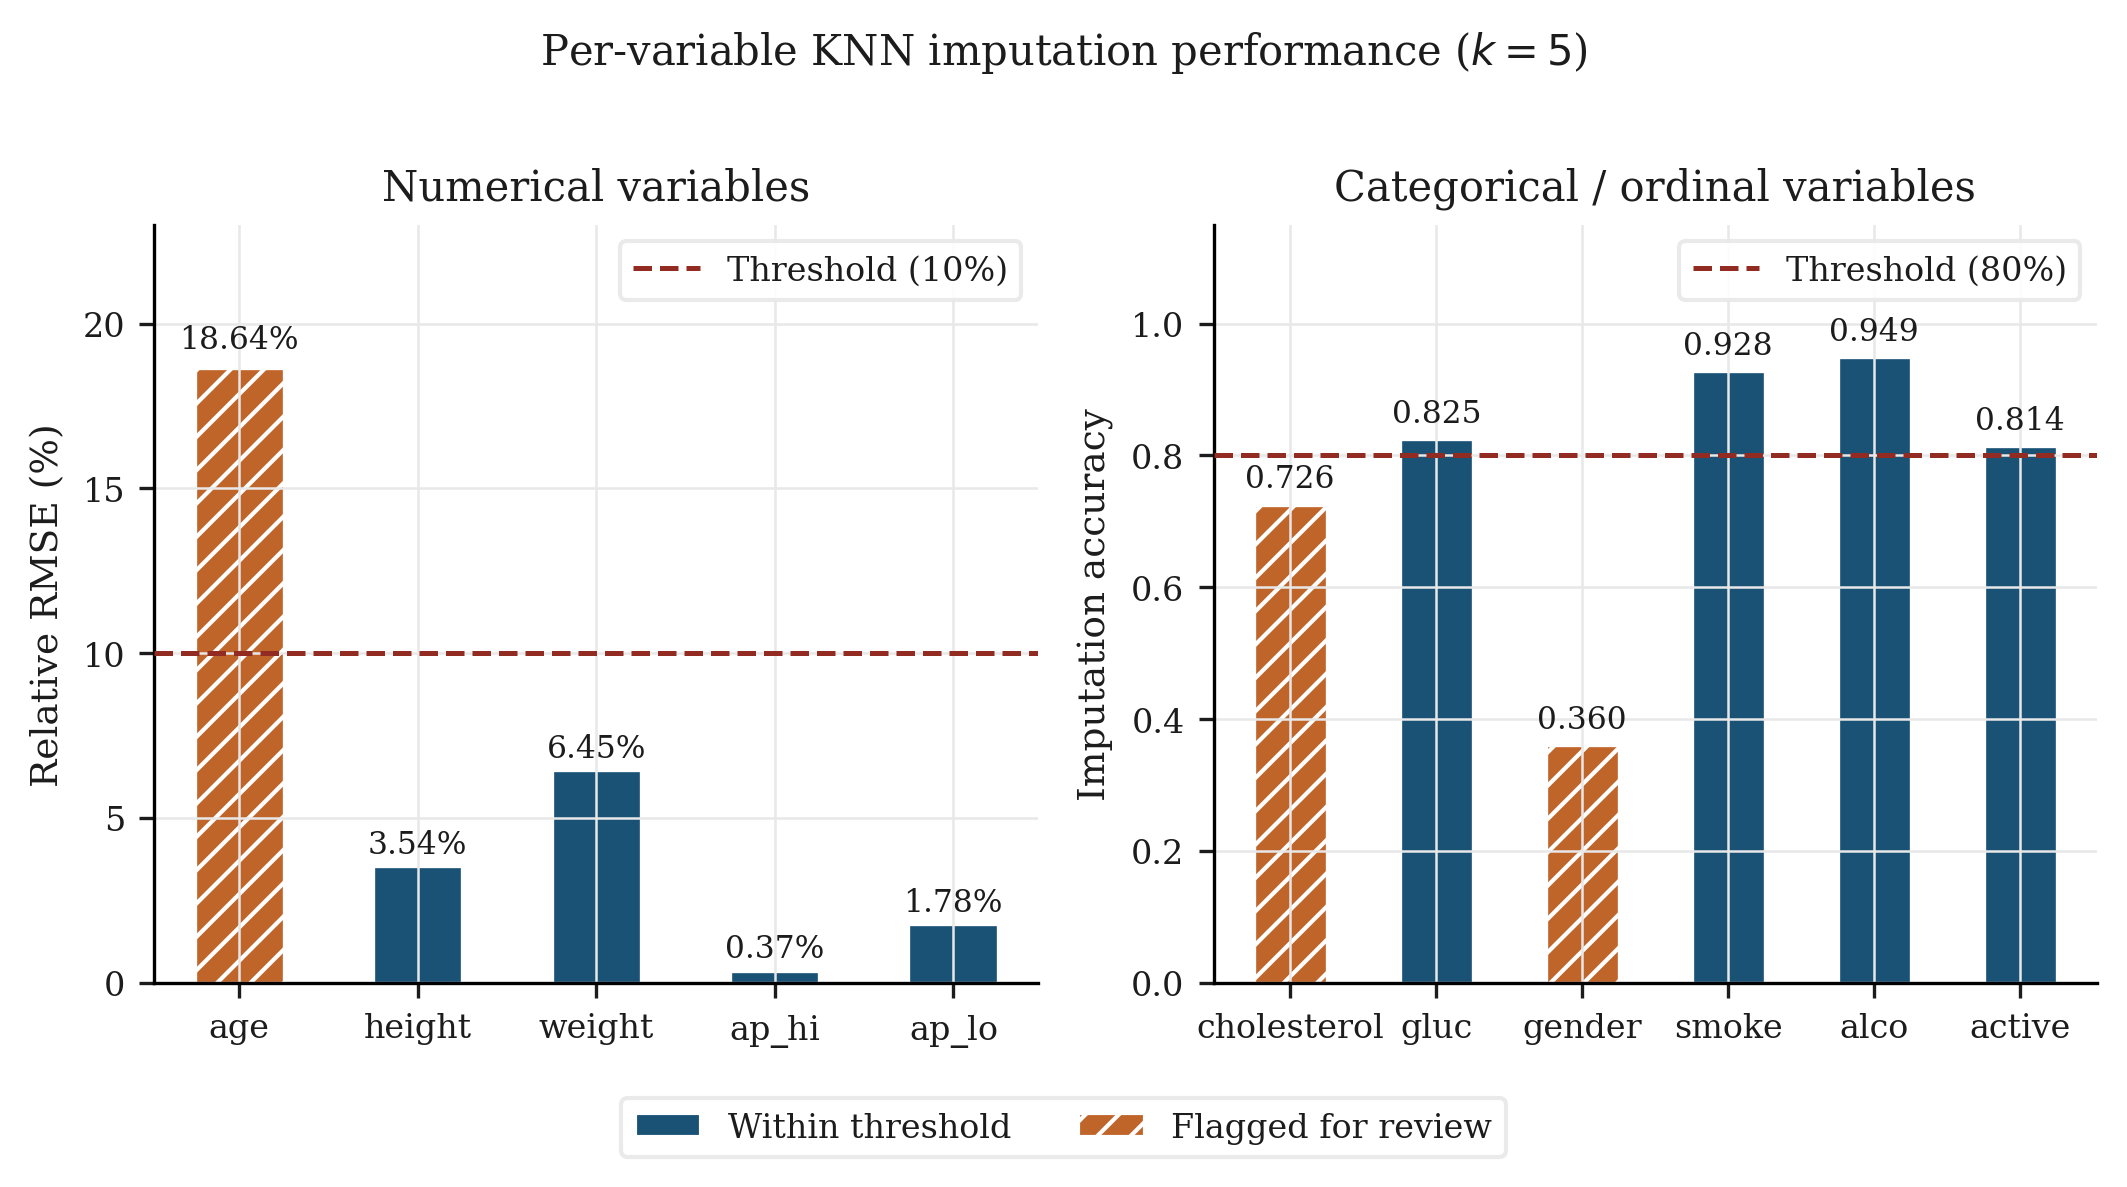

Figura 4 lista.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─────────────────────────────────────────────────────────────
# PALETA UNIFICADA IEEE
# Funciona en color y en escala de grises
# ─────────────────────────────────────────────────────────────
AZUL    = '#1A5276'   # elemento principal / dentro del umbral
NARANJA = '#C0652A'   # elemento secundario / flagged
ROJO    = '#922B21'   # línea de umbral
GRIS    = '#E8E8E8'   # grid suave
TEXTO   = '#1C1C1C'   # texto general

# Configuración global de fuente y estilo (IEEE: mínimo 8pt)
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : GRIS,
    'grid.linewidth'   : 0.6,
    'text.color'       : TEXTO,
    'axes.labelcolor'  : TEXTO,
    'xtick.color'      : TEXTO,
    'ytick.color'      : TEXTO,
})


# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Distribución de NaNs inyectados
# Ancho doble columna IEEE: 7.16 x 3.8 pulgadas
# ══════════════════════════════════════════════════════════════

# Datos — directamente de la salida del pipeline (70,000 pacientes)
variables = ['age', 'height', 'weight', 'ap_hi', 'ap_lo',
             'cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
celdas    = [10500]*5 + [7000]*6
tipos     = ['Numerical (15%)'] * 5 + ['Categorical (10%)'] * 6
colores   = [AZUL]*5 + [NARANJA]*6
# Hatch (rayado) para que funcione en escala de grises
hatches   = ['']*5 + ['///']*6

fig, ax = plt.subplots(figsize=(7.16, 3.8))

bars = ax.barh(variables, celdas,
               color=colores,
               hatch=hatches,
               edgecolor='white',
               height=0.55,
               linewidth=0.8)

# Etiqueta del valor al final de cada barra (fuera, para no chocar)
for bar, val in zip(bars, celdas):
    ax.text(bar.get_width() + 150,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}',
            va='center', ha='left',
            fontsize=8, color=TEXTO)

# Línea vertical en el cambio de tipo de variable
ax.axhline(y=4.5, color=GRIS, linewidth=1.2, linestyle='--')

# Etiquetas de grupo a la derecha del gráfico
ax.text(12800, 2.0, 'Numerical\nvariables',
        fontsize=7.5, color=AZUL, va='center', style='italic')
ax.text(12800, 7.5, 'Categorical\nvariables',
        fontsize=7.5, color=NARANJA, va='center', style='italic')

# Leyenda
patch1 = mpatches.Patch(facecolor=AZUL,    label='Numerical (15% corruption rate)',
                         edgecolor='white')
patch2 = mpatches.Patch(facecolor=NARANJA, hatch='///', label='Categorical (10% corruption rate)',
                         edgecolor='white')
ax.legend(handles=[patch1, patch2],
          loc='lower right',
          framealpha=0.9,
          edgecolor=GRIS)

ax.set_xlabel('Number of masked cells')
ax.set_xlim(0, 13500)
ax.invert_yaxis()
ax.set_title('Distribution of artificially masked values across clinical variables\n'
             'Total: 94,500 cells masked (12.3% of complete feature matrix)',
             pad=10)

plt.tight_layout()
plt.savefig('figura2_nans_inyectados.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura 2 lista.")


# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Selección del hiperparámetro k
# Ancho columna simple IEEE: 3.5 x 3.2 pulgadas
# ══════════════════════════════════════════════════════════════

k_values = [3, 5, 7, 10]
rmse_rel = [5.881, 6.042, 6.137, 6.195]
acc_prom = [76.5,  76.7,  76.1,  76.3]
k_opt    = 5
idx_opt  = k_values.index(k_opt)

fig, ax1 = plt.subplots(figsize=(3.5, 3.2))

# Eje izquierdo: RMSE — línea sólida con círculos
line1, = ax1.plot(k_values, rmse_rel,
                  color=AZUL, marker='o', linewidth=1.8,
                  markersize=5, label='Relative RMSE (%)', zorder=3)
ax1.set_xlabel('Number of neighbors (k)')
ax1.set_ylabel('Mean relative RMSE (%)', color=AZUL)
ax1.tick_params(axis='y', labelcolor=AZUL)
ax1.set_xticks(k_values)
ax1.set_ylim(5.7, 6.4)

# Eje derecho: Accuracy — línea punteada con cuadrados
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)   # mantener estilo limpio en eje gemelo
line2, = ax2.plot(k_values, acc_prom,
                  color=NARANJA, marker='s', linewidth=1.8,
                  markersize=5, linestyle='--',
                  label='Categorical accuracy (%)', zorder=3)
ax2.set_ylabel('Mean categorical accuracy (%)', color=NARANJA)
ax2.tick_params(axis='y', labelcolor=NARANJA)
ax2.set_ylim(75.6, 77.2)

# Línea vertical en k óptimo — discreta
ax1.axvline(x=k_opt, color=ROJO, linewidth=1.0,
            linestyle=':', alpha=0.8, zorder=1)

# Anotación del k óptimo — posicionada para no chocar con nada
ax1.annotate(f'$k^* = {k_opt}$',
             xy=(k_opt, rmse_rel[idx_opt]),
             xytext=(k_opt + 1.5, rmse_rel[idx_opt] - 0.18),
             arrowprops=dict(arrowstyle='->', color=TEXTO,
                             lw=0.8, connectionstyle='arc3,rad=0.2'),
             fontsize=7.5, color=TEXTO,
             bbox=dict(boxstyle='round,pad=0.2', fc='white',
                       ec=GRIS, linewidth=0.6))

# Leyenda unificada — fuera del área de datos para no tapar nada
lines  = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels,
           loc='upper left',
           framealpha=0.9,
           edgecolor=GRIS,
           fontsize=7.5)

ax1.set_title('KNN hyperparameter selection\n'
              r'$k \in \{3, 5, 7, 10\}$', pad=8)

plt.tight_layout()
plt.savefig('figura3_seleccion_k.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura 3 lista.")


# ══════════════════════════════════════════════════════════════
# FIGURA 4 — Métricas de validación por variable (dos paneles)
# Ancho doble columna IEEE: 7.16 x 3.5 pulgadas
# ══════════════════════════════════════════════════════════════

# Datos numéricos
vars_num  = ['age', 'height', 'weight', 'ap$\_$hi', 'ap$\_$lo']
err_rel   = [18.64, 3.54, 6.45, 0.37, 1.78]
umbral_n  = 10.0

# Datos categóricos
vars_cat  = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
acc_cat   = [0.7256, 0.8254, 0.3603, 0.9276, 0.9486, 0.8144]
umbral_c  = 0.80

# Color y hatch según si pasa o no el umbral
def estilo(valores, umbral, menor_es_mejor=True):
    cols = []
    htch = []
    for v in valores:
        pasa = (v <= umbral) if menor_es_mejor else (v >= umbral)
        cols.append(AZUL    if pasa else NARANJA)
        htch.append(''      if pasa else '///')
    return cols, htch

col_n, hatch_n = estilo(err_rel, umbral_n, menor_es_mejor=True)
col_c, hatch_c = estilo(acc_cat, umbral_c, menor_es_mejor=False)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.16, 3.5))

# ─── Panel izquierdo: variables numéricas ───
bars_n = axL.bar(vars_num, err_rel,
                 color=col_n, hatch=hatch_n,
                 edgecolor='white', width=0.5, linewidth=0.8)
axL.axhline(y=umbral_n, color=ROJO, linestyle='--',
            linewidth=1.2, label=f'Threshold ({umbral_n:.0f}%)', zorder=3)

# Etiquetas sobre las barras — con espacio para no chocar
for bar, val in zip(bars_n, err_rel):
    offset = 0.4 if val > umbral_n else 0.2
    axL.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + offset,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=7.5, color=TEXTO)

axL.set_ylabel('Relative RMSE (%)')
axL.set_title('Numerical variables')
axL.set_ylim(0, 23)   # margen superior para que la etiqueta de age no se corte
axL.legend(loc='upper right', framealpha=0.9, edgecolor=GRIS)

# ─── Panel derecho: variables categóricas ───
bars_c = axR.bar(vars_cat, acc_cat,
                 color=col_c, hatch=hatch_c,
                 edgecolor='white', width=0.5, linewidth=0.8)
axR.axhline(y=umbral_c, color=ROJO, linestyle='--',
            linewidth=1.2, label=f'Threshold ({int(umbral_c*100)}%)', zorder=3)

# Etiquetas sobre las barras
for bar, val in zip(bars_c, acc_cat):
    axR.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.015,
             f'{val:.3f}',
             ha='center', va='bottom', fontsize=7.5, color=TEXTO)

axR.set_ylabel('Imputation accuracy')
axR.set_title('Categorical / ordinal variables')
axR.set_ylim(0, 1.15)   # margen para etiquetas superiores
axR.legend(loc='upper right', framealpha=0.9, edgecolor=GRIS)

# Leyenda compartida de pass/fail — debajo de los dos paneles
patch_ok  = mpatches.Patch(facecolor=AZUL,    edgecolor='white',
                            label='Within threshold')
patch_rev = mpatches.Patch(facecolor=NARANJA, edgecolor='white',
                            hatch='///', label='Flagged for review')
fig.legend(handles=[patch_ok, patch_rev],
           loc='lower center', ncol=2,
           fontsize=8, framealpha=0.9,
           edgecolor=GRIS,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Per-variable KNN imputation performance ($k = 5$)',
             fontsize=10, y=1.01)

plt.tight_layout()
plt.savefig('figura4_metricas_validacion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura 4 lista.")